<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Exercise 3 — Input Modeling

Summer Semester 26

Gunther Gust & Govind Rao <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

## Learning Goals

After completing this exercise, you should be able to:

- Apply the **5-step input-modeling process** to real datasets.
- Pick a candidate distribution from theory and from the histogram.
- Fit parameters with `scipy.stats.<dist>.fit(data)` (or closed-form MLE).
- Validate the fit with the **chi-square test** (discrete data) or the **Kolmogorov–Smirnov (KS) test** (continuous data).
- Plug a fitted distribution back into a SimPy simulation as input.

---
## Part A — Call attempts until first connection

A telephone help-line records, for **80 distinct users**, the number of dial attempts each user needed before reaching an agent for the first time (some attempts hit a busy line). Your job: identify a suitable distribution and validate it.

The dataset is loaded below. Treat it as if you observed it in the field.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import random
import simpy

---
## Part A — Help-desk arrivals (discrete, χ² test)

A help desk records the **number of incoming requests per 15-minute window** over 80 working hours. Your job: identify a suitable distribution and validate it.

The dataset is generated below. Treat it as if you observed it in the field.

In [30]:
# Provided — observed call attempts (treat as real measurements)
df_calls = pd.read_csv(r'C:\Users\PC-123\Desktop\repos\s4dm\S4DM-SS26-lectures\data\call_attempts.csv')
attempts = df_calls['attempts'].values
print(df_calls.head())
print(f"\nSample size: {len(attempts)} | min = {attempts.min()}, max = {attempts.max()}")

   user_id  attempts
0        1         1
1        2         1
2        3         2
3        4         4
4        5         2

Sample size: 80 | min = 1, max = 13


### Task A.0 — Data quality check

Before fitting anything, verify the **iid** assumption. Plot a scatter diagram of `attempts[t]` against `attempts[t+1]` and comment on whether consecutive observations look independent.

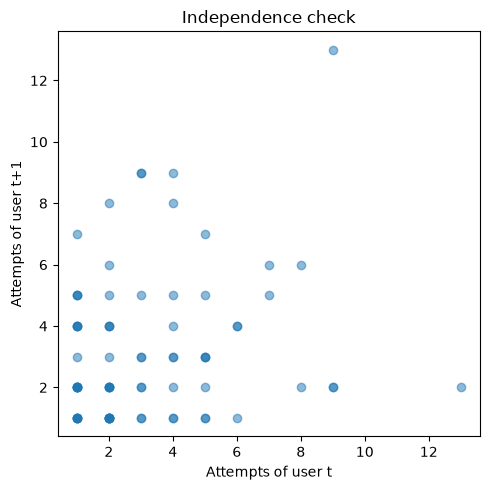

In [31]:
# SOLUTION
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(attempts[:-1], attempts[1:], alpha=0.5, color='#1f77b4')
ax.set_xlabel('Attempts of user t')
ax.set_ylabel('Attempts of user t+1')
ax.set_title('Independence check')
plt.tight_layout(); plt.show()
# No clear pattern → cloud of points, not a line.
# Consecutive observations appear independent — iid assumption is plausible.

### Task A.1 — Visualize and choose a family

1. Plot a histogram with an appropriate number of bins (use one bin per integer value).
2. From **theory** (the underlying mechanism: each call attempt independently succeeds with the same probability $p$) and from the histogram shape: which discrete distribution is the natural candidate?

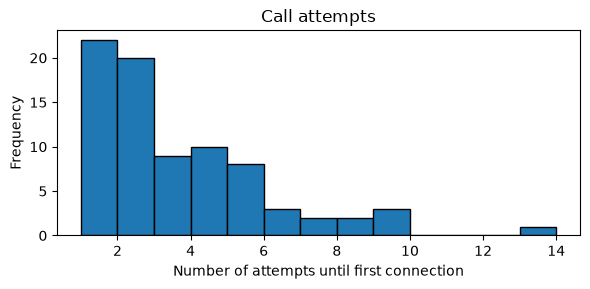

In [32]:
# SOLUTION
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(attempts, bins=range(attempts.min(), attempts.max() + 2),
        edgecolor='black', color='#1f77b4')
ax.set_xlabel('Number of attempts until first connection')
ax.set_ylabel('Frequency')
ax.set_title('Call attempts')
plt.tight_layout(); plt.show()

# Reasoning:
# - Each attempt independently succeeds with the same probability p.
# - We count the number of trials until the FIRST success.
# → candidate distribution: GEOMETRIC(p)

### Task A.2 — Estimate the parameter (MLE)

The closed-form MLE for the Geometric distribution is $\hat p = 1 / \bar x$. Compute it from the data.

In [33]:
# SOLUTION
p_hat = 1 / attempts.mean()
print(f"sample mean = {attempts.mean():.3f}")
print(f"p̂ = 1 / mean = {p_hat:.3f}")

sample mean = 3.212
p̂ = 1 / mean = 0.311


### Task A.3 — Validate with the chi-square test

Bin the data, compute observed ($O_i$) and expected ($E_i$) counts under Geometric($\hat p$), merge bins where $E_i < 5$, then run `scipy.stats.chisquare` with `ddof=1` (since one parameter was estimated). Report the χ² statistic, degrees of freedom, and p-value. State your decision at $\alpha = 0.05$.

> *Hint:* `scipy.stats.geom.pmf(k, p)` returns $P(X = k)$ for $k = 1, 2, \ldots$

In [34]:
# SOLUTION
from scipy.stats import chisquare, geom

# 1) Build observed and expected counts per integer
max_k = attempts.max()
ks_grid = np.arange(1, max_k + 1)
observed = np.array([np.sum(attempts == k) for k in ks_grid])
expected = len(attempts) * geom.pmf(ks_grid, p_hat)
expected[-1] += len(attempts) * (1 - geom.cdf(max_k, p_hat))   # tail

# 2) Merge bins where E < 5
merged_O, merged_E = [], []
buf_O, buf_E = 0, 0
for O, E in zip(observed, expected):
    buf_O += O; buf_E += E
    if buf_E >= 5:
        merged_O.append(buf_O); merged_E.append(buf_E)
        buf_O, buf_E = 0, 0
if buf_O > 0:
    merged_O[-1] += buf_O; merged_E[-1] += buf_E

chi2, p = chisquare(merged_O, merged_E, ddof=1)
df = len(merged_O) - 1 - 1
print(f"k = {len(merged_O)}, df = {df}")
print(f"χ² = {chi2:.3f}, p = {p:.3f}")
print(f"Decision: {'fail to reject H₀ — Geometric fits' if p > 0.05 else 'reject H₀'}")

k = 7, df = 5
χ² = 3.290, p = 0.655
Decision: fail to reject H₀ — Geometric fits


### Task A.4 — Use the fitted distribution in SimPy

Simulate **100 future users** of the help line. For each user, draw the number of attempts from Geometric($\hat p$), and assume each attempt takes 1 minute. Build a small SimPy simulation and report the **average minutes spent dialing per user**.

In [35]:
# SOLUTION
random.seed(0)
env = simpy.Environment()
total_attempts_log = []

class CallingUser:
    def __init__(self, env, name, log):
        self.env = env; self.name = name; self.log = log

    def run(self):
        n_attempts = np.random.geometric(p_hat)
        yield self.env.timeout(n_attempts)        # 1 minute per attempt
        self.log.append(n_attempts)

def gen(env, log, n=100):
    for i in range(n):
        env.process(CallingUser(env, f'U{i}', log).run())
        yield env.timeout(0)                      # all users start at time 0

env.process(gen(env, total_attempts_log))
env.run()
print(f"Users simulated:           {len(total_attempts_log)}")
print(f"Mean attempts per user:    {np.mean(total_attempts_log):.2f}")
print(f"Mean minutes dialing/user: {np.mean(total_attempts_log):.2f} min")

Users simulated:           100
Mean attempts per user:    3.47
Mean minutes dialing/user: 3.47 min


---
## Part B — Assembly cycle times

A factory measures the **cycle time** of an automated assembly station for **200 consecutive cycles**. Each cycle consists of many small standardized sub-operations (welding, fastening, transferring), each with a fixed mean and small independent timing variability.

Your job: identify a suitable continuous distribution and validate it with the **Kolmogorov–Smirnov (KS) test**.

> **Reminder:** the KS test is the standard goodness-of-fit test for **continuous** distributions. It compares the empirical CDF to the theoretical CDF and uses the maximum vertical gap as test statistic.

In [36]:
# Provided — observed cycle times (continuous, in seconds)
df_cycles = pd.read_csv(r'C:\Users\PC-123\Desktop\repos\s4dm\S4DM-SS26-lectures\data\assembly_cycle_times.csv')
cycle_times = df_cycles['cycle_time_sec'].values
print(df_cycles.head())
print(f"\nn = {len(cycle_times)}, mean = {cycle_times.mean():.2f} sec, "
      f"std = {cycle_times.std():.2f} sec")

   cycle_id  cycle_time_sec
0         1           62.00
1         2           60.08
2         3           57.67
3         4           62.85
4         5           62.11

n = 200, mean = 60.04 sec, std = 2.96 sec


### Task B.1 — Visualize and choose a family

1. Plot a histogram with √n bins.
2. From the **theoretical mechanism** described in the scenario above and the shape you see in the histogram, identify the natural continuous candidate distribution. Justify your choice.

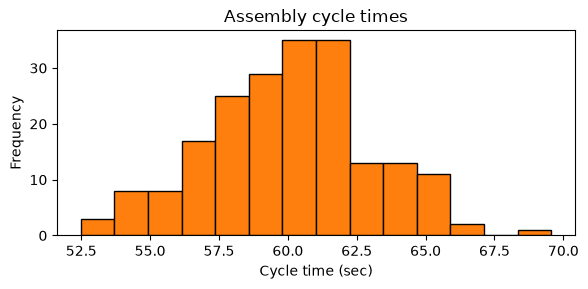

In [37]:
# SOLUTION
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(cycle_times, bins=int(np.sqrt(len(cycle_times))),
        edgecolor='black', color='#ff7f0e')
ax.set_xlabel('Cycle time (sec)')
ax.set_ylabel('Frequency')
ax.set_title('Assembly cycle times')
plt.tight_layout(); plt.show()

# Reasoning:
# - Continuous, symmetric, bell-shaped
# - Total = sum of many small independent sub-operation times
# - Central Limit Theorem → NORMAL distribution

### Task B.2 — Fit parameters

For the Normal distribution, the closed-form MLE is $\hat\mu = \bar x$ and $\hat\sigma^2 = \frac{1}{n}\sum(x_i - \bar x)^2$. You can either compute these directly or use `scipy.stats.norm.fit(data)`, which returns `(loc, scale) = (μ̂, σ̂)`.

In [38]:
# SOLUTION
mu_hat, sigma_hat = stats.norm.fit(cycle_times)
print(f"μ̂ = {mu_hat:.3f} sec")
print(f"σ̂ = {sigma_hat:.3f} sec")

μ̂ = 60.044 sec
σ̂ = 2.961 sec


### Task B.3 — Apply the KS test

Use `scipy.stats.kstest` to compare the data against the fitted Normal distribution. Report the KS statistic $D$ and the p-value, then state your decision at $\alpha = 0.05$.

```python
stats.kstest(data, 'norm', args=(loc, scale))
```

In [39]:
# SOLUTION
ks_stat, p_value = stats.kstest(cycle_times, 'norm', args=(mu_hat, sigma_hat))
print(f"KS statistic D = {ks_stat:.4f}")
print(f"p-value        = {p_value:.4f}")
print(f"Decision: {'fail to reject H₀ — Normal fits' if p_value > 0.05 else 'reject H₀'}")

TypeError: ndtr() takes from 1 to 2 positional arguments but 3 were given

### Task B.3b — Compare with an Exponential fit

The Exponential distribution is **monotonically decreasing** and concentrated near zero — completely different in shape from a symmetric bell. Fit an Exponential to the same data and run the KS test. Compare the two p-values: what does the result tell you about the importance of matching the *shape* of the data to the candidate distribution?

In [ ]:
# SOLUTION
loc_e, scale_e = stats.expon.fit(cycle_times, floc=0)
ks_stat_e, p_value_e = stats.kstest(cycle_times, 'expon', args=(loc_e, scale_e))
print(f"Normal:      D = {ks_stat:.4f}, p = {p_value:.4g}")
print(f"Exponential: D = {ks_stat_e:.4f}, p = {p_value_e:.4g}")
# Observation:
# - Normal: very small D, very high p — symmetric bell matches perfectly.
# - Exponential: huge D, p ≈ 0 — completely wrong shape (monotonically decreasing).
# Lesson: match the SHAPE of the candidate to what you see in the histogram.
# A formal test cannot rescue a candidate from the wrong family.

### Task B.4 — QQ-plot (visual check)

Produce a QQ-plot of the data against the fitted Normal. Are the points close to the line $y = x$?

In [ ]:
# SOLUTION
fig, ax = plt.subplots(figsize=(5, 5))
n = len(cycle_times)
sorted_data = np.sort(cycle_times)
p_i = (np.arange(1, n + 1) - 0.5) / n
theoretical = stats.norm.ppf(p_i, loc=mu_hat, scale=sigma_hat)
ax.scatter(theoretical, sorted_data, alpha=0.5, color='#ff7f0e')
mn, mx = sorted_data.min(), sorted_data.max()
ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Theoretical quantile (Normal)')
ax.set_ylabel('Observed quantile')
ax.set_title('QQ-plot: cycle times vs. Normal')
ax.legend(); plt.tight_layout(); plt.show()

---
## Part C — New process: no data, only expert estimates

A consultant is asked to model a **new manual inspection step** in a production line. No data exists yet. The shop floor manager provides three estimates:

- **Minimum** time: 3 min
- **Most likely**: 5 min
- **Maximum**: 12 min

Your job: pick an appropriate distribution given the information available, and use it as a SimPy input.

### Task C.1 — Pick a distribution and explain why

Which distribution is the natural choice when only min, most-likely, and max are known? Justify in one sentence.

**Answer:**

The natural choice is the **Triangular distribution** with parameters $(\text{min}=3, \text{mode}=5, \text{max}=12)$. It captures the three elicited values directly and concentrates probability near the most-likely value, which is more informative than a Uniform distribution that would assign equal probability across the entire range.

### Task C.2 — Use your distribution in SimPy

Build a small SimPy simulation using the distribution you chose in C.1: **20 parts arrive every 4 minutes**; each is inspected by a **single inspector** (the inspection time is drawn from your distribution). Report the average wait time and average total time per part.

In [ ]:
# SOLUTION
random.seed(0)
LOW, MODE, HIGH = 3, 5, 12

class Inspector:
    def __init__(self, env):
        self.env = env
        self.bench = simpy.Resource(env, capacity=1)

class Part:
    def __init__(self, env, name, inspector, log):
        self.env = env; self.name = name; self.inspector = inspector; self.log = log

    def run(self):
        arrive = self.env.now
        with self.inspector.bench.request() as req:
            yield req
            wait = self.env.now - arrive
            yield self.env.timeout(random.triangular(LOW, HIGH, MODE))
            self.log.append((wait, self.env.now - arrive))

def gen(env, inspector, log, n=20):
    for i in range(n):
        yield env.timeout(4)
        env.process(Part(env, f'P{i}', inspector, log).run())

env = simpy.Environment()
inspector = Inspector(env)
log = []
env.process(gen(env, inspector, log))
env.run()
waits, totals = zip(*log)
print(f"Parts inspected: {len(log)}")
print(f"Mean wait:       {np.mean(waits):.2f} min")
print(f"Mean total time: {np.mean(totals):.2f} min")

---
## Part D — Help-desk service times

A help desk records the **service time** of every closed request — 200 observations in total. Your job: identify a suitable distribution. As always, start with the histogram.

In [ ]:
# Provided — observed service times
df_mix = pd.read_csv('data/helpdesk_service_times.csv')
times_all = df_mix['service_time_min'].values
print(df_mix.head())
print(f"\nn = {len(times_all)}, mean = {times_all.mean():.2f}, "
      f"min = {times_all.min():.2f}, max = {times_all.max():.2f}")

### Task D.1 — Visualize the full dataset

Plot a histogram of all 200 service times. What unusual feature do you notice?

In [ ]:
# SOLUTION
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(times_all, bins=int(np.sqrt(len(times_all))),
        edgecolor='black', color='#ff7f0e')
ax.set_xlabel('Service time (min)')
ax.set_ylabel('Frequency')
ax.set_title('All help-desk service times')
plt.tight_layout(); plt.show()

# Observation:
# The histogram is BIMODAL — two clear peaks (around 2 min and around 15 min).
# A single distribution will not fit this shape.

### Task D.2 — Investigate and fit

The shape you observed in D.1 suggests the data may not come from a single homogeneous group. Look at the dataset carefully: is there any additional information that could explain what you see? Use it to break the data into meaningful subsets, plot each subset separately, and fit a suitable distribution to each one. Report the estimated parameters and briefly explain why fitting a single distribution to the combined data would have been misleading.

In [ ]:
# SOLUTION
# --- Step 1: plot per group ---
fig, ax = plt.subplots(figsize=(7, 3))
for group, color in [('simple', '#1f77b4'), ('complex', '#ff7f0e')]:
    sub = df_mix[df_mix['request_type'] == group]['service_time_min']
    ax.hist(sub, bins=int(np.sqrt(len(sub))),
            edgecolor='black', color=color, alpha=0.7, label=group)
ax.set_xlabel('Service time (min)')
ax.set_ylabel('Frequency')
ax.set_title('Service times split by request_type')
ax.legend(); plt.tight_layout(); plt.show()

# --- Step 2: fit Lognormal to each subset ---
for group in ['simple', 'complex']:
    sub = df_mix[df_mix['request_type'] == group]['service_time_min'].values
    sigma, loc, scale = stats.lognorm.fit(sub, floc=0)
    mu = np.log(scale)
    print(f"{group:8s}: n = {len(sub):3d}, μ̂ = {mu:.3f}, σ̂ = {sigma:.3f}")

# A single distribution fitted to the combined data would have been a Frankenstein:
# its mean would land between the two peaks where almost no observations lie,
# and the chi-square / KS tests would (correctly) reject it.
# Splitting respects the underlying data-generating mechanism.

---
## Short Questions

*The following questions are comparable to exam questions in format and expected answer length. Note that content-wise they are on the harder end — use them to stress-test your understanding.*

**Q1** — The following 10 service times (in minutes) were recorded at a help desk:

| # | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| Time | 2.1 | 8.3 | 0.5 | 5.7 | 1.2 | 3.8 | 9.1 | 0.3 | 4.6 | 6.2 |

Fit an Exponential distribution to this data. State the MLE formula, compute the estimated parameter, and write down the fitted density function.

**Answer:** The MLE for the rate parameter of an Exponential distribution is $\hat{\lambda} = 1/\bar{x}$.

$$\bar{x} = \frac{2.1 + 8.3 + 0.5 + 5.7 + 1.2 + 3.8 + 9.1 + 0.3 + 4.6 + 6.2}{10} = \frac{41.8}{10} = 4.18$$

$$\hat{\lambda} = \frac{1}{4.18} \approx 0.239$$

The fitted density function is:

$$f(x) = \hat{\lambda}\, e^{-\hat{\lambda}\, x} = 0.239\, e^{-0.239\, x}, \quad x \geq 0$$

**Q2** — Two analysts model the same arrival process. Both estimate a mean inter-arrival time of 5 minutes from data. Analyst A fits Exponential(mean=5); Analyst B fits Normal(mean=5, std=0.5). The same SimPy queueing model is used otherwise, yet the predicted average waiting times differ by an order of magnitude. Explain why, and state which fit is likely correct given the underlying mechanism of arrivals.

**Answer:** Both fits have the same mean, but very different variance.

- The **Exponential** has CV = 1 (high variance) — it generates bursts of very short inter-arrivals followed by long gaps. Bursts cause queues to build faster than they drain, driving up waiting times.
- The **Normal with σ = 0.5** is near-deterministic — arrivals are almost evenly spaced, so queues barely form.

**Same mean, very different variance → very different queue behavior.**

Analyst A (Exponential) is theoretically justified: if arrivals come from many independent customers acting independently, the memoryless property arises naturally. Normal would only suit nearly *scheduled* arrivals (e.g. buses on a strict timetable), which is rare for human-generated traffic.

**Q3** — You run a KS test on 50 service times and fail to reject H₀ (the candidate Exponential fits, p = 0.3). A colleague says: *"Great, we have proven the data is Exponential."* Critique this conclusion. Discuss (a) what failing to reject actually proves, (b) the role of the sample size, and (c) what additional evidence you would gather before relying on the fit.

**Answer:**

**(a)** Failing to reject is *not* the same as proving H₀ is true. It only means the data is *compatible* with the candidate — many other distributions might also pass. Statistical tests can only reject hypotheses, never confirm them.

**(b)** With n = 50, the test has *low power* (high β). Even moderate misfits likely escape detection. A non-rejection from a small sample is weak evidence in favor of the fit; with a larger sample, the same misfit could lead to rejection as the sampling distribution narrows.

**(c)** Additional evidence to gather:
- **QQ-plot** — points should lie close to the diagonal; systematic curvature signals a poor fit.
- **CDF overlay** — empirical vs. theoretical CDF should overlap.
- **Theoretical justification** — does the memoryless assumption hold for this process?
- **Sensitivity analysis** — would simulation conclusions change if Gamma or Weibull were used instead?

---
## Wrap-up — reflect

Answer each of the following questions in the markdown cell directly below it.

**1. Part A** — Why did we use `ddof=1` in the chi-square test? What would happen if we forgot it?

**Answer:** `ddof=1` reduces the degrees of freedom from $k-1$ to $k-1-1 = k-2$ to account for the fact that we estimated **one parameter** from the data. The general rule is $df = k - 1 - p$ where $p$ is the number of estimated parameters.

If we forgot it, `scipy.stats.chisquare` would assume the parameter was *known* and use $df = k-1$ — a larger $df$ shifts the chi-square distribution to the right, so the same $\chi^2$ value yields an artificially **larger p-value**. The test becomes too lenient and fails to reject bad fits as often as it should.

**2. Part B** — What does a *high* p-value (e.g. 0.7) tell you about your fit? What does it *not* prove?

**Answer:** It tells you the data is **compatible** with the candidate distribution — there is no statistical evidence against the fit at the chosen $\alpha$.

It does **not** prove the candidate is the correct distribution. Many other distributions could also be compatible, especially with limited sample size (low test power). The KS test (and any goodness-of-fit test) can only **reject** hypotheses, never **confirm** them. A high p-value with $n=30$ is much weaker evidence than a high p-value with $n=500$.

**3. Part C** — Why is the distribution you chose in Part C a better choice than `Uniform(low, high)` when you also know the most-likely value?

**Answer:** The distribution chosen in C.1 (Triangular) concentrates probability mass near the **mode** (most-likely value), reflecting the expert's belief that this value is more probable than the extremes. Uniform spreads probability *equally* across $[a, b]$ — including values near the boundaries that the expert considers unlikely.

Using Uniform when the mode is known throws away genuine information from the expert. Triangular preserves it with one extra parameter.

**4. Cross-cutting** — When would a *visual* check (QQ-plot, histogram) lead you to reject a candidate distribution even if the formal test gives a high p-value?

**Answer:** Several scenarios:

- **Bimodal histogram** — a single distribution may pass on aggregate moments but completely miss the two-peak structure (exactly what we saw in Part D).
- **Systematic tail deviation in the QQ-plot** — points consistently below or above $y=x$ in the tails signal wrong tail behavior, even if the bulk of points pass.
- **Visible time trend or autocorrelation in a scatter check** — the iid assumption is violated; goodness-of-fit tests don't check independence.
- **Prior domain knowledge** — the distribution may pass statistically but be physically implausible (e.g. predicting negative service times).